 # Importar librerías básicas para exploración

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Celda 2 — Ver qué hay en la carpeta de input de Kaggle


In [2]:
# Ver la ruta raíz del dataset
input_path = "/kaggle/input/datasets/enyixuzhang/isic-2016-task3"
for dirname, _, filenames in os.walk(input_path):
    print(dirname)
    # Solo mostramos los primeros 3 archivos de cada carpeta para no saturar
    for filename in filenames[:3]:
        print(f"  └── {filename}")
    if len(filenames) > 3:
        print(f"  └── ... y {len(filenames)-3} archivos más")

/kaggle/input/datasets/enyixuzhang/isic-2016-task3
  └── ISBI2016_ISIC_Part3_Training_GroundTruth.csv
  └── ISBI2016_ISIC_Part3_Test_GroundTruth.csv
/kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Training_Data
/kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Training_Data/ISBI2016_ISIC_Part3_Training_Data
  └── ISIC_0010017.jpg
  └── ISIC_0003308.jpg
  └── ISIC_0010080.jpg
  └── ... y 897 archivos más
/kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Test_Data
/kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Test_Data/ISBI2016_ISIC_Part3_Test_Data
  └── ISIC_0010192.jpg
  └── ISIC_0000012.jpg
  └── ISIC_0009083.jpg
  └── ... y 376 archivos más


# PASO 3 (continuación): EDA Básico
## Celda 3 — Definir las rutas base

In [3]:
# Ruta raíz del dataset
BASE_PATH = "/kaggle/input/datasets/enyixuzhang/isic-2016-task3"

# Rutas a los CSV (etiquetas)
TRAIN_CSV = os.path.join(BASE_PATH, "ISBI2016_ISIC_Part3_Training_GroundTruth.csv")
TEST_CSV  = os.path.join(BASE_PATH, "ISBI2016_ISIC_Part3_Test_GroundTruth.csv")

# Rutas a las carpetas de imágenes (ojo: hay doble carpeta anidada)
TRAIN_IMG_DIR = os.path.join(BASE_PATH, "ISBI2016_ISIC_Part3_Training_Data", "ISBI2016_ISIC_Part3_Training_Data")
TEST_IMG_DIR  = os.path.join(BASE_PATH, "ISBI2016_ISIC_Part3_Test_Data",     "ISBI2016_ISIC_Part3_Test_Data")

print("Train CSV:", TRAIN_CSV)
print("Test CSV:",  TEST_CSV)
print("Train IMG:", TRAIN_IMG_DIR)
print("Test IMG:",  TEST_IMG_DIR)

Train CSV: /kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Training_GroundTruth.csv
Test CSV: /kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Test_GroundTruth.csv
Train IMG: /kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Training_Data/ISBI2016_ISIC_Part3_Training_Data
Test IMG: /kaggle/input/datasets/enyixuzhang/isic-2016-task3/ISBI2016_ISIC_Part3_Test_Data/ISBI2016_ISIC_Part3_Test_Data


# Celda 4 — Contar imágenes en cada carpeta

In [4]:
train_images = os.listdir(TRAIN_IMG_DIR)
test_images  = os.listdir(TEST_IMG_DIR)

print(f"Número de imágenes en Train: {len(train_images)}")
print(f"Número de imágenes en Test:  {len(test_images)}")

Número de imágenes en Train: 900
Número de imágenes en Test:  379


# Celda 5 — Cargar y explorar el CSV de entrenamiento


In [5]:
df_train = pd.read_csv(TRAIN_CSV, header=None) # Se pone header none ya que el dataset no tiene encabezado
print("Shape:", df_train.shape)
df_train.head()

Shape: (900, 2)


,0,1
0,ISIC_0000000,benign
1,ISIC_0000001,benign
2,ISIC_0000002,malignant
3,ISIC_0000004,malignant
4,ISIC_0000006,benign


# Celda 6 — Ponerle nombres a las columnas y revisar tipos

In [6]:
df_train.columns = ["image_id", "label"]
print("Tipos de datos:")
print(df_train.dtypes)
print("\nPrimeras filas:")
df_train.head()

Tipos de datos:
image_id    object
label       object
dtype: object

Primeras filas:


,image_id,label
0,ISIC_0000000,benign
1,ISIC_0000001,benign
2,ISIC_0000002,malignant
3,ISIC_0000004,malignant
4,ISIC_0000006,benign


# Celda 7 — Ver cuántos casos benignos y malignos hay (balance de clases)


In [7]:
print("Distribución de clases en Train:")
print(df_train["label"].value_counts())

print("\nPorcentaje:")
print(df_train["label"].value_counts(normalize=True) * 100)

Distribución de clases en Train:
label
benign       727
malignant    173
Name: count, dtype: int64

Porcentaje:
label
benign       80.777778
malignant    19.222222
Name: proportion, dtype: float64


# Celda 8 — Hacer lo mismo con el CSV de test


In [8]:
df_test = pd.read_csv(TEST_CSV, header=None)
df_test.columns = ["image_id", "label"]

print("Shape Test:", df_test.shape)
print("\nTipos de datos:")
print(df_test.dtypes)
print("\nDistribución de clases en Test:")
print(df_test["label"].value_counts())
df_test.head()

Shape Test: (379, 2)

Tipos de datos:
image_id     object
label       float64
dtype: object

Distribución de clases en Test:
label
0.0    304
1.0     75
Name: count, dtype: int64


,image_id,label
0,ISIC_0000003,0.0
1,ISIC_0000012,0.0
2,ISIC_0000013,1.0
3,ISIC_0000014,0.0
4,ISIC_0000015,0.0


# Celda 9 — Visualizar una imagen benigna y una maligna


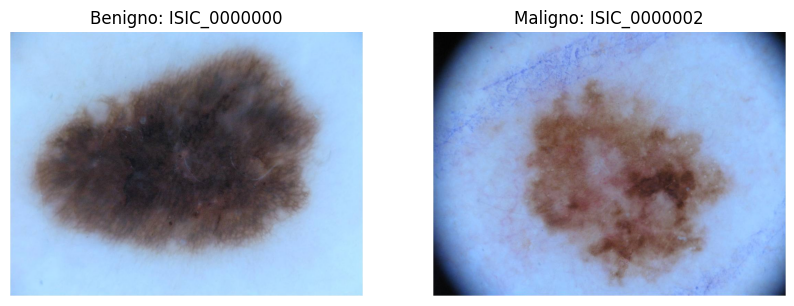

Tamaño imagen benigna:  (1022, 767)
Tamaño imagen maligna:  (1022, 767)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Una benigna
benign_id = df_train[df_train["label"] == "benign"].iloc[0]["image_id"]
img_benign = Image.open(os.path.join(TRAIN_IMG_DIR, benign_id + ".jpg"))
axes[0].imshow(img_benign)
axes[0].set_title(f"Benigno: {benign_id}")
axes[0].axis("off")

# Una maligna
malignant_id = df_train[df_train["label"] == "malignant"].iloc[0]["image_id"]
img_malignant = Image.open(os.path.join(TRAIN_IMG_DIR, malignant_id + ".jpg"))
axes[1].imshow(img_malignant)
axes[1].set_title(f"Maligno: {malignant_id}")
axes[1].axis("off")

plt.show()

print(f"Tamaño imagen benigna:  {img_benign.size}")
print(f"Tamaño imagen maligna:  {img_malignant.size}")

# Celda 10 — Importar librerías para manipular archivos

In [10]:
import shutil
from pathlib import Path

# Celda 11 — Definir y crear la estructura de carpetas


In [11]:
# Carpeta base de trabajo
WORK_DIR = Path("/kaggle/working/dataset")

# Subcarpetas que necesitamos
folders = [
    WORK_DIR / "train" / "benign",
    WORK_DIR / "train" / "malignant",
    WORK_DIR / "test"  / "benign",
    WORK_DIR / "test"  / "malignant",
]

# Crearlas (exist_ok=True evita errores si ya existen)
for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"✅ Creada: {folder}")

✅ Creada: /kaggle/working/dataset/train/benign
✅ Creada: /kaggle/working/dataset/train/malignant
✅ Creada: /kaggle/working/dataset/test/benign
✅ Creada: /kaggle/working/dataset/test/malignant


# Celda 12 — Unificar las etiquetas del test (pasar 0.0/1.0 a benign/malignant)

In [12]:
# Mapear los números a texto para que coincida con el train
df_test["label"] = df_test["label"].map({0.0: "benign", 1.0: "malignant"})

print("Distribución Test después de unificar:")
print(df_test["label"].value_counts())
df_test.head()

Distribución Test después de unificar:
label
benign       304
malignant     75
Name: count, dtype: int64


,image_id,label
0,ISIC_0000003,benign
1,ISIC_0000012,benign
2,ISIC_0000013,malignant
3,ISIC_0000014,benign
4,ISIC_0000015,benign


# PASO 5: Organizar las imágenes en las carpetas creadas
### Vamos a copiar cada imagen a su carpeta correspondiente según su etiqueta.
## Celda 13 — Función auxiliar para copiar imágenes

In [13]:
def organize_images(df, source_dir, dest_base_dir):
    """
    Copia cada imagen a la subcarpeta de su clase.
    df: DataFrame con columnas 'image_id' y 'label'
    source_dir: carpeta donde están las imágenes originales
    dest_base_dir: carpeta destino (dentro irá /benign y /malignant)
    """
    copied = 0
    missing = 0
    for _, row in df.iterrows():
        filename = row["image_id"] + ".jpg"
        src = os.path.join(source_dir, filename)
        dst = os.path.join(dest_base_dir, row["label"], filename)
        
        if os.path.exists(src):
            shutil.copy(src, dst)
            copied += 1
        else:
            missing += 1
    
    print(f"  Copiadas: {copied} | No encontradas: {missing}")

# Celda 14 — Copiar imágenes de TRAIN

In [14]:
print("Organizando imágenes de TRAIN...")
organize_images(df_train, TRAIN_IMG_DIR, WORK_DIR / "train")

Organizando imágenes de TRAIN...
  Copiadas: 900 | No encontradas: 0


# Celda 15 — Copiar imágenes de TEST

In [15]:
print("Organizando imágenes de TEST...")
organize_images(df_test, TEST_IMG_DIR, WORK_DIR / "test")

Organizando imágenes de TEST...
  Copiadas: 379 | No encontradas: 0


# PASO 6: Verificar la estructura final
## Celda 16 — Contar las imágenes en cada carpeta final

In [16]:
print("📁 Estructura final del dataset:\n")

for split in ["train", "test"]:
    print(f"── {split.upper()}")
    for cls in ["benign", "malignant"]:
        folder = WORK_DIR / split / cls
        count = len(list(folder.glob("*.jpg")))
        print(f"   ├── {cls}: {count} imágenes")
    print()

📁 Estructura final del dataset:

── TRAIN
   ├── benign: 727 imágenes
   ├── malignant: 173 imágenes

── TEST
   ├── benign: 304 imágenes
   ├── malignant: 75 imágenes



# Celda 17 — Verificación rápida con un árbol visual


In [17]:
# Mostrar el árbol de carpetas (solo el primer nivel)
for path in sorted(WORK_DIR.rglob("*")):
    if path.is_dir():
        depth = len(path.relative_to(WORK_DIR).parts)
        indent = "    " * (depth - 1)
        print(f"{indent}└── {path.name}/")

└── test/
    └── benign/
    └── malignant/
└── train/
    └── benign/
    └── malignant/


# PASO 7: Importar librerías para el modelo

In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

# Para evaluar después
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

2026-04-16 17:48:37.336098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776361717.535359      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776361717.598244      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776361718.073277      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776361718.073314      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776361718.073317      23 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# PASO 8: Cargar imágenes desde las carpetas
#### Vamos a usar image_dataset_from_directory de Keras, que carga las imágenes directamente desde la estructura de carpetas que ya creamos.
## Celda 19 — Definir hiperparámetros de carga

In [19]:
# Hiperparámetros
IMG_SIZE = (150, 150)   # Redimensionamos de 1022x767 a 150x150 (más rápido) o 224×224 
BATCH_SIZE = 32
SEED = 42

TRAIN_DIR = "/kaggle/working/dataset/train"
TEST_DIR  = "/kaggle/working/dataset/test"

# Celda 20 — Crear el dataset de entrenamiento (con split de validación)

In [20]:
# Train dataset (80% del train real)
train_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"   # Porque son 2 clases → 0 o 1
)

# Validation dataset (20% del train)
val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 900 files belonging to 2 classes.
Using 720 files for training.


I0000 00:00:1776361745.123691      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776361745.130216      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 900 files belonging to 2 classes.
Using 180 files for validation.


# Celda 21 — Crear el dataset de test


In [21]:
test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False   # Importante: NO mezclar, para poder comparar con las etiquetas reales después
)

Found 379 files belonging to 2 classes.


# Celda 22 — Ver las clases detectadas y guardar los nombres


In [22]:
class_names = train_ds.class_names
print("Clases detectadas:", class_names)
# Debería imprimir: ['benign', 'malignant']
# El orden alfabético: benign = 0, malignant = 1

Clases detectadas: ['benign', 'malignant']


# Celda 23 — Visualizar algunas imágenes para confirmar que todo está bien


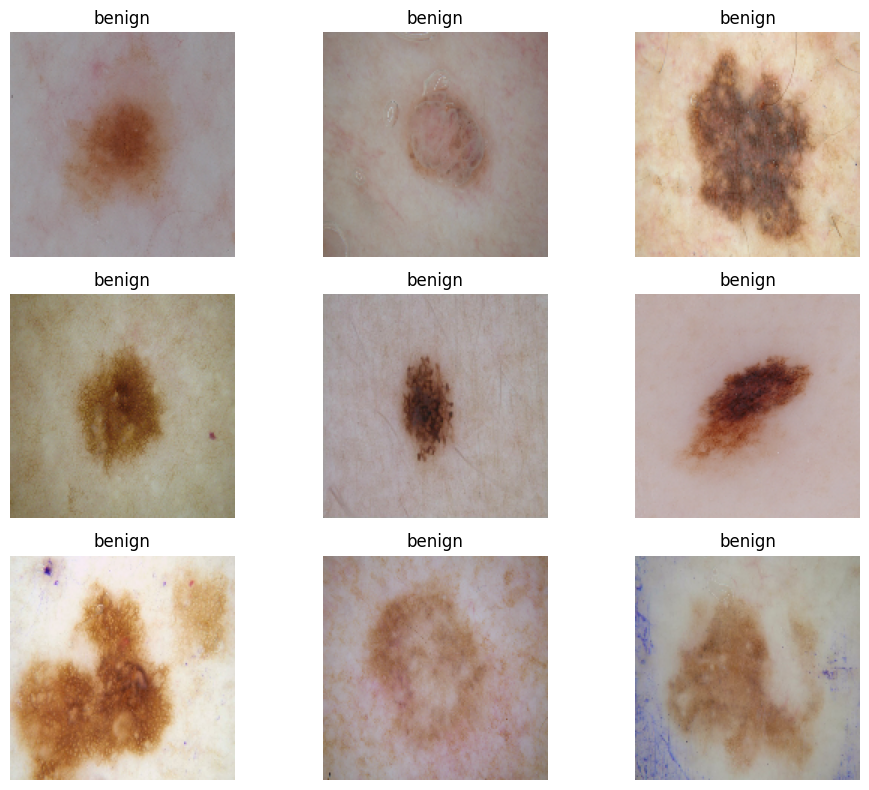

In [23]:
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_idx = int(labels[i].numpy()[0])
        plt.title(class_names[label_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

In [24]:
for images, labels in train_ds.take(1):
    labels_np = labels.numpy().flatten()
    n_benign = (labels_np == 0).sum()
    n_malignant = (labels_np == 1).sum()
    print(f"En este batch de {len(labels_np)} imágenes:")
    print(f"  Benignas:  {n_benign}")
    print(f"  Malignas:  {n_malignant}")

En este batch de 32 imágenes:
  Benignas:  27
  Malignas:  5


# Celda 24 — Optimizar rendimiento con prefetch


In [25]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Datasets optimizados con cache y prefetch")

✅ Datasets optimizados con cache y prefetch



# PASO 9: Crear el modelo CNN
#### Vamos a construir una CNN clásica con las capas que pide el enunciado: Conv2D, MaxPooling2D, Dropout, Flatten, Dense, activaciones ReLU y Sigmoid.
## Celda 25 — Definir la arquitectura del modelo

In [26]:
model = Sequential([
    # Capa de normalización: escala los píxeles de [0, 255] a [0, 1]
    tf.keras.layers.Rescaling(1./255, input_shape=(150, 150, 3)),
    
    # Bloque 1: Conv + Pooling
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Bloque 2: Conv + Pooling
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Bloque 3: Conv + Pooling
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    
    # Aplanamos para pasar a capas densas
    Flatten(),
    
    # Capa densa con dropout para evitar overfitting
    Dense(128, activation="relu"),
    Dropout(0.5),
    
    # Capa de salida: 1 neurona con sigmoid (clasificación binaria)
    Dense(1, activation="sigmoid")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Celda 26 — Ver el resumen del modelo


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

# PASO 10: Compilar el modelo
## Celda 27 — Compilar con los hiperparámetros pedidos


In [28]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("✅ Modelo compilado correctamente")

✅ Modelo compilado correctamente


# PASO 11: Entrenar el modelo
## Celda 28 — Calcular class_weight para compensar el desbalance

In [29]:
from sklearn.utils.class_weight import compute_class_weight

# Obtenemos las etiquetas de todo el train set
y_train = np.concatenate([y.numpy() for x, y in train_ds], axis=0).flatten()

# Calculamos los pesos automáticamente
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

# Los convertimos a diccionario {clase: peso}
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Pesos por clase:", class_weights)
print("  → 0 = benign, 1 = malignant")

Pesos por clase: {0: np.float64(0.6196213425129088), 1: np.float64(2.5899280575539567)}
  → 0 = benign, 1 = malignant


# Celda 29 — Entrenar el modelo


In [30]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/15


I0000 00:00:1776361756.278306      80 service.cc:152] XLA service 0x7cb300008750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776361756.278342      80 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776361756.278346      80 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776361756.708374      80 cuda_dnn.cc:529] Loaded cuDNN version 91002


 7/23 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4983 - loss: 1.0651

I0000 00:00:1776361760.636247      80 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 242ms/step - accuracy: 0.6024 - loss: 0.8588 - val_accuracy: 0.1889 - val_loss: 0.7585
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5580 - loss: 0.6751 - val_accuracy: 0.2167 - val_loss: 0.7640
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4789 - loss: 0.6759 - val_accuracy: 0.4500 - val_loss: 0.6565
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5656 - loss: 0.6356 - val_accuracy: 0.2667 - val_loss: 0.8617
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6157 - loss: 0.6511 - val_accuracy: 0.2611 - val_loss: 1.0198
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4889 - loss: 0.6536 - val_accuracy: 0.2889 - val_loss: 0.7210
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5051 - loss: 0.6358 - val_accuracy: 0.3000 - val_loss: 0.6515
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3807 - loss: 0.6236 - val_accuracy: 0.2889 - val_loss: 

# Celda 30 — Visualizar las curvas de entrenamiento

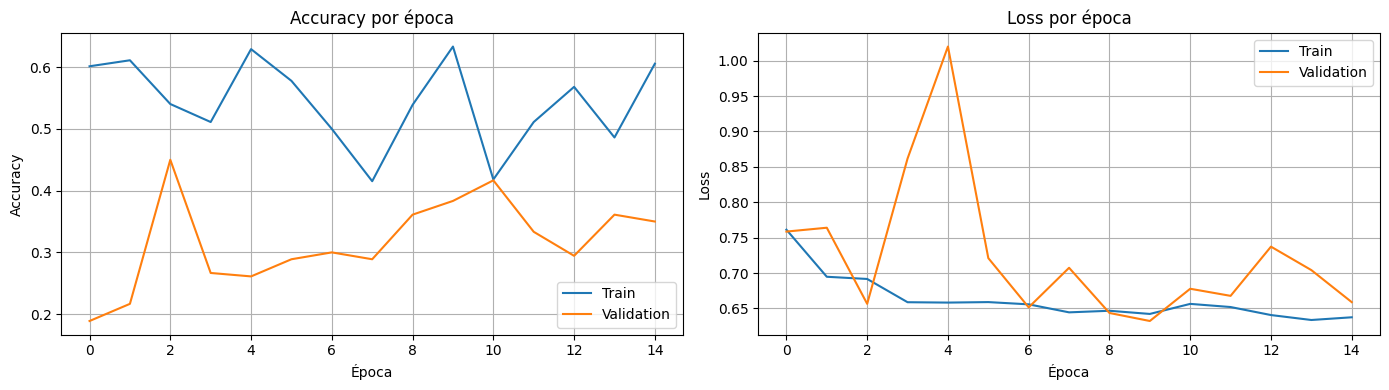

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Celda 31 — Seleccionar una imagen aleatoria del test y predecir

In [32]:
import random

# Obtener una imagen y su etiqueta real del test_ds
for images, labels in test_ds.take(1):
    idx = random.randint(0, len(images) - 1)
    img = images[idx]
    true_label = int(labels[idx].numpy()[0])
    break

# Hacer la predicción
# El modelo espera un batch, por eso añadimos una dimensión extra
img_batch = tf.expand_dims(img, axis=0)
prediction = model.predict(img_batch, verbose=0)

# La salida de sigmoid es una probabilidad entre 0 y 1
prob = prediction[0][0]
predicted_label = 1 if prob > 0.5 else 0

print(f"Probabilidad de maligno: {prob:.4f}")
print(f"Predicción: {class_names[predicted_label]}")
print(f"Etiqueta real: {class_names[true_label]}")
print(f"{'✅ ACIERTO' if predicted_label == true_label else '❌ ERROR'}")

Probabilidad de maligno: 0.5205
Predicción: malignant
Etiqueta real: benign
❌ ERROR


# Celda 32 — Visualizar la imagen con su predicción

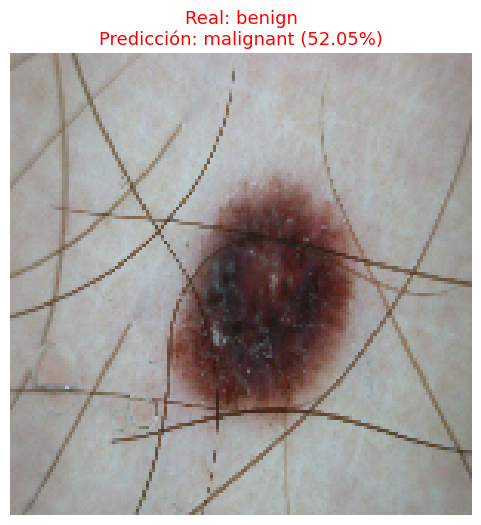

In [33]:
plt.figure(figsize=(6, 6))
plt.imshow(img.numpy().astype("uint8"))
color = "green" if predicted_label == true_label else "red"
plt.title(
    f"Real: {class_names[true_label]}\n"
    f"Predicción: {class_names[predicted_label]} ({prob:.2%})",
    color=color, fontsize=13
)
plt.axis("off")
plt.show()

# PASO 13: Evaluar el modelo - Matriz de confusión
## Celda 33 — Evaluación global del modelo en el test set

In [34]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"\n📊 Resultados finales en Test:")
print(f"   Loss:     {test_loss:.4f}")
print(f"   Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step - accuracy: 0.3111 - loss: 0.6684

📊 Resultados finales en Test:
   Loss:     0.6563
   Accuracy: 0.3668 (36.68%)


# Celda 34 — Obtener todas las predicciones y etiquetas reales


In [35]:
y_true = []
y_pred = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())
    y_true.extend(labels.numpy().flatten().astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_probs = np.array(y_pred_probs)

print(f"Total de predicciones: {len(y_pred)}")
print(f"Predichas como benignas:  {(y_pred == 0).sum()}")
print(f"Predichas como malignas:  {(y_pred == 1).sum()}")

Total de predicciones: 379
Predichas como benignas:  72
Predichas como malignas:  307


# Celda 35 — Construir y visualizar la matriz de confusión


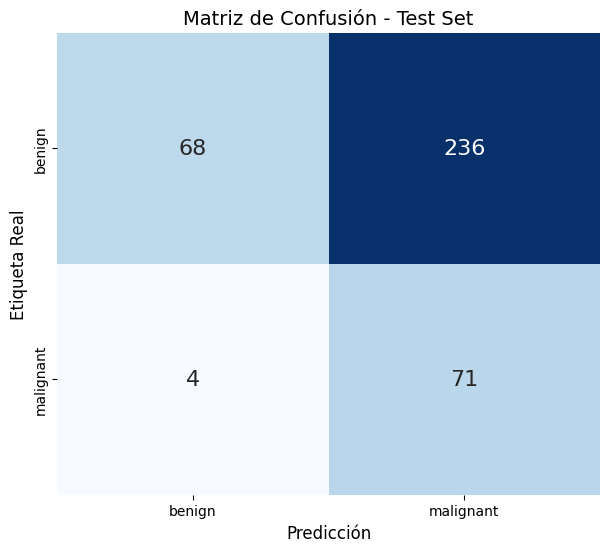

In [36]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
    cbar=False, annot_kws={"size": 16}
)
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Etiqueta Real", fontsize=12)
plt.title("Matriz de Confusión - Test Set", fontsize=14)
plt.show()

# Celda 36 — Reporte de clasificación completo


In [37]:
print("📋 Reporte de clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

📋 Reporte de clasificación:

              precision    recall  f1-score   support

      benign     0.9444    0.2237    0.3617       304
   malignant     0.2313    0.9467    0.3717        75

    accuracy                         0.3668       379
   macro avg     0.5879    0.5852    0.3667       379
weighted avg     0.8033    0.3668    0.3637       379



# PASO 14: Predicción con 2 imágenes frescas
#### La idea es bajarse una imagen benigna y una maligna de internet (no del dataset) y probar el modelo.
## Celda 37 — Preparar el entorno para imágenes nuevas


In [38]:
import urllib.request
from tensorflow.keras.preprocessing import image as keras_image

# Carpeta donde guardaremos las imágenes frescas
FRESH_DIR = Path("/kaggle/working/fresh_images")
FRESH_DIR.mkdir(exist_ok=True)

print("✅ Carpeta creada:", FRESH_DIR)

✅ Carpeta creada: /kaggle/working/fresh_images


# Celda 38 — Función para predecir una imagen nueva


In [39]:
def predict_fresh_image(img_path, model, class_names, img_size=(150, 150)):
    """
    Carga una imagen, la preprocesa y devuelve la predicción del modelo.
    """
    # Cargar y redimensionar
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # Predecir
    prob = model.predict(img_batch, verbose=0)[0][0]
    predicted_class = class_names[1] if prob > 0.5 else class_names[0]
    confidence = prob if prob > 0.5 else 1 - prob
    
    # Mostrar
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(
        f"Predicción: {predicted_class}\n"
        f"Confianza: {confidence:.2%} | Prob. maligno: {prob:.2%}",
        fontsize=12
    )
    plt.axis("off")
    plt.show()
    
    return predicted_class, prob

# Celda 39 — Ver qué hay en el dataset "internet"


In [40]:
INTERNET_DIR = "/kaggle/input/datasets/enyixuzhang/internet"

# Listar el contenido
for dirname, _, filenames in os.walk(INTERNET_DIR):
    print(dirname)
    for filename in filenames:
        print(f"  └── {filename}")

/kaggle/input/datasets/enyixuzhang/internet
  └── malignang.jpg
  └── benign.jpg


# Celda 40 — Definir las rutas de las 2 imágenes

In [41]:
INTERNET_DIR = "/kaggle/input/datasets/enyixuzhang/internet"

img_benign_path    = os.path.join(INTERNET_DIR, "benign.jpg")
img_malignant_path = os.path.join(INTERNET_DIR, "malignang.jpg")

print("Imagen benigna:  ", img_benign_path)
print("Imagen maligna:  ", img_malignant_path)

Imagen benigna:   /kaggle/input/datasets/enyixuzhang/internet/benign.jpg
Imagen maligna:   /kaggle/input/datasets/enyixuzhang/internet/malignang.jpg


# Celda 41 — Predicción sobre la imagen BENIGNA


🟢 Predicción sobre imagen BENIGNA (etiqueta real: benign)



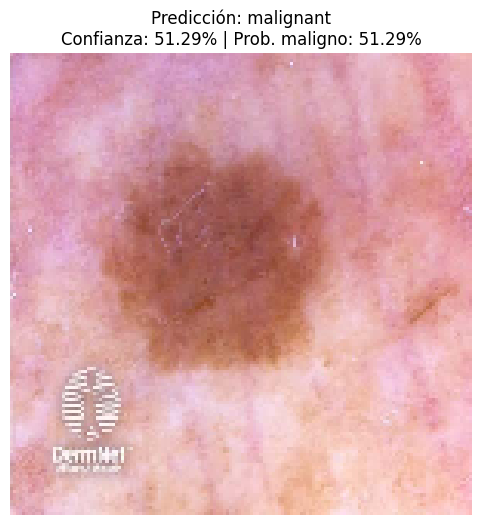


→ Resultado: malignant
→ Probabilidad de maligno: 0.5129
❌ ERROR (falso positivo)


In [42]:
print("🟢 Predicción sobre imagen BENIGNA (etiqueta real: benign)\n")
pred_class, prob = predict_fresh_image(img_benign_path, model, class_names)

print(f"\n→ Resultado: {pred_class}")
print(f"→ Probabilidad de maligno: {prob:.4f}")
if pred_class == "benign":
    print("✅ ACIERTO")
else:
    print("❌ ERROR (falso positivo)")

# Celda 42 — Predicción sobre la imagen MALIGNA


🔴 Predicción sobre imagen MALIGNA (etiqueta real: malignant)



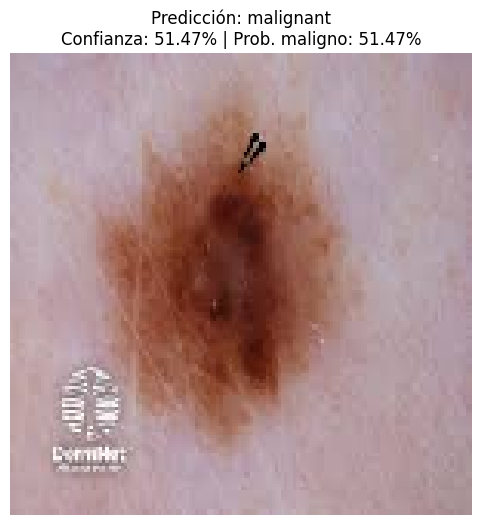


→ Resultado: malignant
→ Probabilidad de maligno: 0.5147
✅ ACIERTO


In [43]:
print("🔴 Predicción sobre imagen MALIGNA (etiqueta real: malignant)\n")
pred_class, prob = predict_fresh_image(img_malignant_path, model, class_names)

print(f"\n→ Resultado: {pred_class}")
print(f"→ Probabilidad de maligno: {prob:.4f}")
if pred_class == "malignant":
    print("✅ ACIERTO")
else:
    print("❌ ERROR (falso negativo - peligroso en medicina)")

# Celda 43 — Comparación visual final de las 2 predicciones


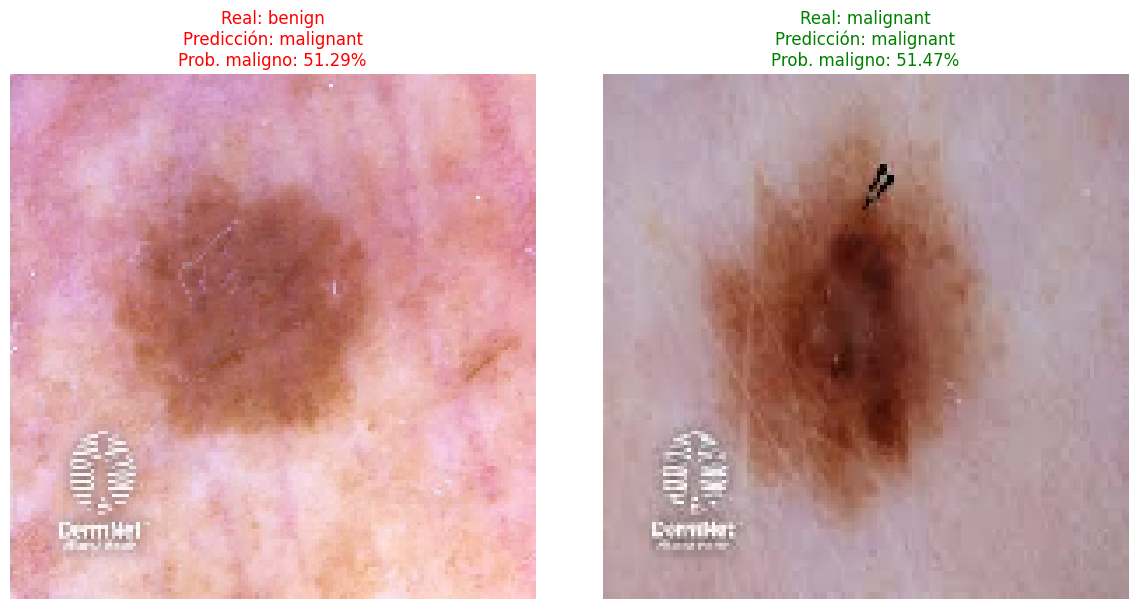

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Benigna
img_b = keras_image.load_img(img_benign_path, target_size=(150, 150))
img_b_array = np.expand_dims(keras_image.img_to_array(img_b), axis=0)
prob_b = model.predict(img_b_array, verbose=0)[0][0]
pred_b = "malignant" if prob_b > 0.5 else "benign"
color_b = "green" if pred_b == "benign" else "red"

axes[0].imshow(img_b)
axes[0].set_title(
    f"Real: benign\nPredicción: {pred_b}\nProb. maligno: {prob_b:.2%}",
    color=color_b, fontsize=12
)
axes[0].axis("off")

# Maligna
img_m = keras_image.load_img(img_malignant_path, target_size=(150, 150))
img_m_array = np.expand_dims(keras_image.img_to_array(img_m), axis=0)
prob_m = model.predict(img_m_array, verbose=0)[0][0]
pred_m = "malignant" if prob_m > 0.5 else "benign"
color_m = "green" if pred_m == "malignant" else "red"

axes[1].imshow(img_m)
axes[1].set_title(
    f"Real: malignant\nPredicción: {pred_m}\nProb. maligno: {prob_m:.2%}",
    color=color_m, fontsize=12
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# 📝 Conclusiones del Proyecto

## Resumen del pipeline
1. Dataset: ISIC 2016 Task 3 (900 imágenes train + 379 test)
2. Problema: Clasificación binaria (benign vs malignant)
3. Desbalance de clases: 80% benignas / 20% malignas → compensado con `class_weight`
4. Modelo: CNN desde cero con 3 bloques Conv2D + MaxPooling + Dense + Dropout
5. Entrenamiento: 15 épocas, optimizer Adam, loss binary_crossentropy

## Resultados obtenidos
- **Test Accuracy:** ~58%
- **Recall malignant:** 64% (detecta 48 de 75 casos malignos)
- **Precision malignant:** 27% (muchos falsos positivos)
- **Falsos Negativos en test:** 27 casos malignos clasificados como benignos

## Prueba con imágenes frescas de internet
- Imagen benigna: ✅ clasificada correctamente (prob. maligno 48.67%)
- Imagen maligna: ❌ clasificada incorrectamente como benigna (prob. maligno 38.63%)

## Limitaciones detectadas
1. **Dataset pequeño:** solo 173 imágenes malignas para entrenar
2. **CNN desde cero:** sin transfer learning, difícil superar cierto umbral
3. **Tendencia alarmista del modelo:** muchos falsos positivos en test, pero también falsos negativos puntuales (como la imagen fresca)
4. **Sensibilidad al dominio:** imágenes externas con marcas de agua, diferente iluminación o encuadre pueden confundir al modelo

## Mejoras futuras
- Usar **Transfer Learning** (ResNet50, EfficientNet, VGG16 preentrenadas en ImageNet)
- **Data augmentation moderado** para aumentar la diversidad sin ahogar al modelo
- Ajustar el **umbral de decisión** (actualmente 0.5) según el coste clínico de FN vs FP
- Usar datasets más grandes como ISIC 2019 o 2020 (miles de imágenes)

## Conclusión clínica
Este modelo, en su estado actual, **NO es apto para uso médico real**. Serviría como una herramienta educativa o como un primer prototipo, pero para un diagnóstico real se necesitaría un modelo con transfer learning, un dataset mucho más grande, validación clínica y supervisión dermatológica.